# PART 1

In [31]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, precision_score, precision_recall_fscore_support, recall_score, average_precision_score, confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter


import shap
import lightgbm as lgb
import xgboost as xgb
import catboost as cb


In [33]:
df_raw = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/FINAL EXAMINATION/Data_For Midterm and Final Project.xlsx")
df = df_raw.copy()
selected_columns = [
    'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',"OPEN_DATE","NGAYDENHAN",
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT',"NHOMNOMOI"
]

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90344 entries, 0 to 90343
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MJACCTTYPCD          90344 non-null  object 
 1   PHUONG THUC CHO VAY  90344 non-null  object 
 2   LOAIKH               90344 non-null  int64  
 3   SEX                  86014 non-null  object 
 4   BASE_BAL             90344 non-null  float64
 5   CURR_BAL             90344 non-null  float64
 6   DUNO_QD              90344 non-null  float64
 7   CURRENCYCD           90344 non-null  object 
 8   OPEN_DATE            90344 non-null  object 
 9   NGAYDENHAN           90344 non-null  object 
 10  ID_TIME              90344 non-null  int64  
 11  DESC_TIME            90344 non-null  object 
 12  MJACCTTYPDESC        90344 non-null  object 
 13  ORGNBR               90344 non-null  int64  
 14  ORGNAME              90344 non-null  object 
 15  PARENTORGNBR         90344 non-null 

In [35]:
df.describe()

,LOAIKH,BASE_BAL,CURR_BAL,DUNO_QD,ID_TIME,ORGNBR,PARENTORGNBR,LAISUAT,NHOMNO,NHOMNOMOI
count,90344.000000,9.034400e+04,9.034400e+04,9.034400e+04,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000
mean,1.015950,3.824727e+08,3.492253e+08,3.504023e+08,1.306041,62.705703,44.470435,0.090739,1.260183,1.278491
std,0.125283,4.389216e+09,3.828898e+09,3.830033e+09,0.615677,36.059407,33.218565,0.055570,0.881587,0.901262
min,1.000000,2.000000e+00,1.000000e+00,1.000000e+00,1.000000,3.000000,3.000000,0.000000,1.000000,1.000000
25%,1.000000,2.200000e+07,3.000000e+07,3.000000e+07,1.000000,33.000000,19.000000,0.000000,1.000000,1.000000
50%,1.000000,1.200000e+08,1.100000e+08,1.100000e+08,1.000000,66.000000,34.000000,0.111000,1.000000,1.000000
75%,1.000000,3.000000e+08,3.000000e+08,3.000000e+08,1.000000,90.000000,73.000000,0.129000,1.000000,1.000000
max,2.000000,3.850000e+11,3.127000e+11,3.127000e+11,3.000000,138.000000,138.000000,0.950000,5.000000,5.000000


Filter dataframe

In [36]:
df[['LOAIKH', 'BASE_BAL', 'CURR_BAL','DUNO_QD','ID_TIME']].describe()

,LOAIKH,BASE_BAL,CURR_BAL,DUNO_QD,ID_TIME
count,90344.000000,9.034400e+04,9.034400e+04,9.034400e+04,90344.000000
mean,1.015950,3.824727e+08,3.492253e+08,3.504023e+08,1.306041
std,0.125283,4.389216e+09,3.828898e+09,3.830033e+09,0.615677
min,1.000000,2.000000e+00,1.000000e+00,1.000000e+00,1.000000
25%,1.000000,2.200000e+07,3.000000e+07,3.000000e+07,1.000000
50%,1.000000,1.200000e+08,1.100000e+08,1.100000e+08,1.000000
75%,1.000000,3.000000e+08,3.000000e+08,3.000000e+08,1.000000
max,2.000000,3.850000e+11,3.127000e+11,3.127000e+11,3.000000


In [37]:
df[['ORGNBR', 'PARENTORGNBR', 'LAISUAT','NHOMNO','NHOMNOMOI']].describe()

,ORGNBR,PARENTORGNBR,LAISUAT,NHOMNO,NHOMNOMOI
count,90344.000000,90344.000000,90344.000000,90344.000000,90344.000000
mean,62.705703,44.470435,0.090739,1.260183,1.278491
std,36.059407,33.218565,0.055570,0.881587,0.901262
min,3.000000,3.000000,0.000000,1.000000,1.000000
25%,33.000000,19.000000,0.000000,1.000000,1.000000
50%,66.000000,34.000000,0.111000,1.000000,1.000000
75%,90.000000,73.000000,0.129000,1.000000,1.000000
max,138.000000,138.000000,0.950000,5.000000,5.000000


In [38]:
df = df[selected_columns]

Copy for processing

In [39]:
df["OPEN_DATE_clean"] = pd.NaT

For rows with numeric values ​​(serial date)

In [40]:
mask_numeric = df["OPEN_DATE"].apply(lambda x: str(x).replace('.', '').isnumeric())

The line is a valid date string.

In [41]:
mask_string = ~mask_numeric

Apply conversions to each type

In [42]:
df.loc[mask_numeric, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_numeric, "OPEN_DATE"].astype(float),
                                                         origin="1899-12-30", unit="D", errors="coerce")

df.loc[mask_string, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_string, "OPEN_DATE"],
                                                        format="%d/%m/%Y", errors="coerce")

Check the results

In [ ]:
print(df[["OPEN_DATE", "OPEN_DATE_clean"]].head())

    OPEN_DATE OPEN_DATE_clean
0  28/12/2010      2010-12-28
1       40490      2010-11-08
2  27/05/2010      2010-05-27
3       40276      2010-04-08
4  23/06/2010      2010-06-23


In [44]:
invalid_dates = df[df["OPEN_DATE_clean"].isna()]

In [45]:
num_invalid = invalid_dates.shape[0]
print(f"Số lượng giá trị lỗi trong OPEN_DATE_clean: {num_invalid}")

Số lượng giá trị lỗi trong OPEN_DATE_clean: 0


In [46]:
if num_invalid > 0:
    print("📋 Các giá trị gốc bị lỗi khi chuyển datetime:")
    display(invalid_dates[["OPEN_DATE"]].drop_duplicates().head(10))
else:
    print("Không có lỗi nào trong OPEN_DATE_clean — tất cả đã chuyển đổi thành datetime thành công.")

Không có lỗi nào trong OPEN_DATE_clean — tất cả đã chuyển đổi thành datetime thành công.


Make clean column default to NaT

In [47]:
df["NGAYDENHAN_clean"] = pd.NaT

Mask number: check if it is Excel serial number

In [48]:
mask_numeric_ngay = df["NGAYDENHAN"].apply(lambda x: str(x).replace('.', '').isnumeric())

The rest is a series of days (reverse mask)

In [49]:
mask_string_ngay = ~mask_numeric_ngay

Convert numeric values ​​(Excel serial)

In [50]:
df.loc[mask_numeric_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_numeric_ngay, "NGAYDENHAN"].astype(float),
    origin="1899-12-30", unit="D", errors="coerce"
)

Convert string value

In [51]:
df.loc[mask_string_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_string_ngay, "NGAYDENHAN"],
    format="%d/%m/%Y", errors="coerce"
)

Check for error values ​​(NaT)

In [52]:
invalid_ngay = df[df["NGAYDENHAN_clean"].isna()]

Count the number of errors

In [53]:
num_invalid_ngay = invalid_ngay.shape[0]
print(f"Số lượng lỗi trong NGAYDENHAN_clean: {num_invalid_ngay}")

Số lượng lỗi trong NGAYDENHAN_clean: 0


Show some example error values

In [54]:
if num_invalid_ngay > 0:
    print(" Các giá trị gốc bị lỗi khi chuyển datetime:")
    display(invalid_ngay[["NGAYDENHAN"]].drop_duplicates().head(10))
else:
    print("Không có lỗi nào trong NGAYDENHAN_clean — tất cả đã chuyển đổi thành datetime thành công.")

df[["OPEN_DATE_clean", "NGAYDENHAN_clean"]].head()

Không có lỗi nào trong NGAYDENHAN_clean — tất cả đã chuyển đổi thành datetime thành công.


,OPEN_DATE_clean,NGAYDENHAN_clean
0,2010-12-28,2020-03-12
1,2010-11-08,2030-07-28
2,2010-05-27,2030-05-26
3,2010-04-08,2013-04-08
4,2010-06-23,2030-06-23


Check min and max of OPEN_DATE_clean

In [55]:
open_min = df["OPEN_DATE_clean"].min()
open_max = df["OPEN_DATE_clean"].max()

Check min and max of NgayDENHAN_clean

In [56]:
due_min = df["NGAYDENHAN_clean"].min()
due_max = df["NGAYDENHAN_clean"].max()

Print results

In [57]:
print("Thông tin thời gian:")
print(f"OPEN_DATE_clean: từ {open_min.date()} đến {open_max.date()}")
print(f"NGAYDENHAN_clean: từ {due_min.date()} đến {due_max.date()}")

Thông tin thời gian:
OPEN_DATE_clean: từ 2004-02-04 đến 2020-12-08
NGAYDENHAN_clean: từ 2006-11-27 đến 2121-04-30


In [58]:
# Bước 1: Xác định giá trị cần sửa
wrong_date = pd.to_datetime("2121-04-30")
correct_date = pd.to_datetime("2021-04-30")

# Bước 2: Cập nhật lại
df.loc[df["NGAYDENHAN_clean"] == wrong_date, "NGAYDENHAN_clean"] = correct_date

# Bước 3: Kiểm tra lại
print("Đã cập nhật xong. Kiểm tra các giá trị có thể từng sai:")
print(df[df["NGAYDENHAN_clean"] == correct_date][["NGAYDENHAN", "NGAYDENHAN_clean"]].head())

Đã cập nhật xong. Kiểm tra các giá trị có thể từng sai:
       NGAYDENHAN NGAYDENHAN_clean
61352  30/04/2021       2021-04-30
63687  30/04/2021       2021-04-30
66008  30/04/2021       2021-04-30
68990  30/04/2021       2021-04-30
70131  30/04/2021       2021-04-30


In [67]:
# Chọn các cột cần thiết
selected_columns = [
    'LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME',
    'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY',"OPEN_DATE","NGAYDENHAN",
    'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT',"NHOMNOMOI", 'NHOMNO'
]

In [68]:
df = df[selected_columns]

In [69]:
# Xử lý ngày tháng cho OPEN_DATE
df["OPEN_DATE_clean"] = pd.NaT
mask_numeric = df["OPEN_DATE"].apply(lambda x: str(x).replace('.', '').isnumeric())
mask_string = ~mask_numeric

df.loc[mask_numeric, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_numeric, "OPEN_DATE"].astype(float),
                                                         origin="1899-12-30", unit="D", errors="coerce")
df.loc[mask_string, "OPEN_DATE_clean"] = pd.to_datetime(df.loc[mask_string, "OPEN_DATE"],
                                                        format="%d/%m/%Y", errors="coerce")

# Xử lý ngày tháng cho NGAYDENHAN
df["NGAYDENHAN_clean"] = pd.NaT
mask_numeric_ngay = df["NGAYDENHAN"].apply(lambda x: str(x).replace('.', '').isnumeric())
mask_string_ngay = ~mask_numeric_ngay

df.loc[mask_numeric_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_numeric_ngay, "NGAYDENHAN"].astype(float),
    origin="1899-12-30", unit="D", errors="coerce"
)
df.loc[mask_string_ngay, "NGAYDENHAN_clean"] = pd.to_datetime(
    df.loc[mask_string_ngay, "NGAYDENHAN"],
    format="%d/%m/%Y", errors="coerce"
)

# Sửa lỗi năm 2121 thành 2021
wrong_date = pd.to_datetime("2121-04-30")
correct_date = pd.to_datetime("2021-04-30")
df.loc[df["NGAYDENHAN_clean"] == wrong_date, "NGAYDENHAN_clean"] = correct_date

# Tạo các biến thời gian
df["OPEN_YEAR"] = df["OPEN_DATE_clean"].dt.year
df["OPEN_MONTH"] = df["OPEN_DATE_clean"].dt.month
df["OPEN_DAYOFWEEK"] = df["OPEN_DATE_clean"].dt.dayofweek

df["DUE_YEAR"] = df["NGAYDENHAN_clean"].dt.year
df["DUE_MONTH"] = df["NGAYDENHAN_clean"].dt.month
df["DUE_DAYOFWEEK"] = df["NGAYDENHAN_clean"].dt.dayofweek

# Chuẩn hóa giới tính
sex_mapping = {
    'ONG': 'MR', 'MR': 'MR',
    'BA': 'MRS', 'MRS': 'MRS', 'MS': 'MRS'
}
df['SEX'] = df['SEX'].map(sex_mapping).fillna('UNKNOWN')

In [70]:
# ===== THAY ĐỔI CHÍNH: Tạo biến target với 5 nhóm =====
# Kiểm tra phân bố của NHOMNOMOI
print("Phân bố NHOMNO gốc:")
print(df['NHOMNO'].value_counts().sort_index())

Phân bố NHOMNO gốc:
NHOMNO
1    81202
2     3197
3     1155
4     1161
5     3629
Name: count, dtype: int64



Phân bố target mới (5 nhóm):
target
1    26594
2    53579
3     6519
4       23
5     3629
Name: count, dtype: int64

Tỷ lệ phần trăm:
target
1    29.436377
2    59.305543
3     7.215753
4     0.025458
5     4.016869
Name: proportion, dtype: float64


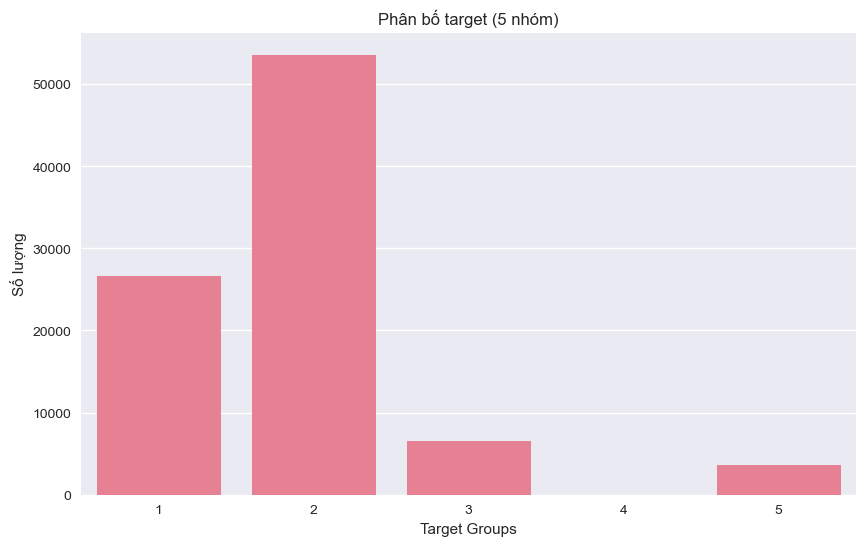


Categorical columns: ['LOAIKH', 'SEX', 'CURRENCYCD', 'DESC_TIME', 'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY', 'NHOMNO', 'OPEN_MONTH', 'OPEN_DAYOFWEEK', 'DUE_MONTH', 'DUE_DAYOFWEEK']
Numeric columns: ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'OPEN_YEAR', 'DUE_YEAR']

Phân bố sau SMOTE:
Counter({2: 26790, 1: 26790, 5: 26790, 3: 26790, 4: 26790})
Kích thước tập train sau biến đổi: (45172, 314)
Kích thước tập test sau biến đổi: (45172, 314)
Kích thước tập train sau SMOTE: (133950, 314)

LOGISTIC REGRESSION
Classification Report:
              precision    recall  f1-score   support

     Group 1       0.98      0.98      0.98     13297
     Group 2       0.99      0.98      0.98     26789
     Group 3       0.93      0.99      0.96      3259
     Group 4       0.80      1.00      0.89        12
     Group 5       1.00      1.00      1.00      1815

    accuracy                           0.98     45172
   macro avg       0.94      0.99      0.96     45172
weighted avg  

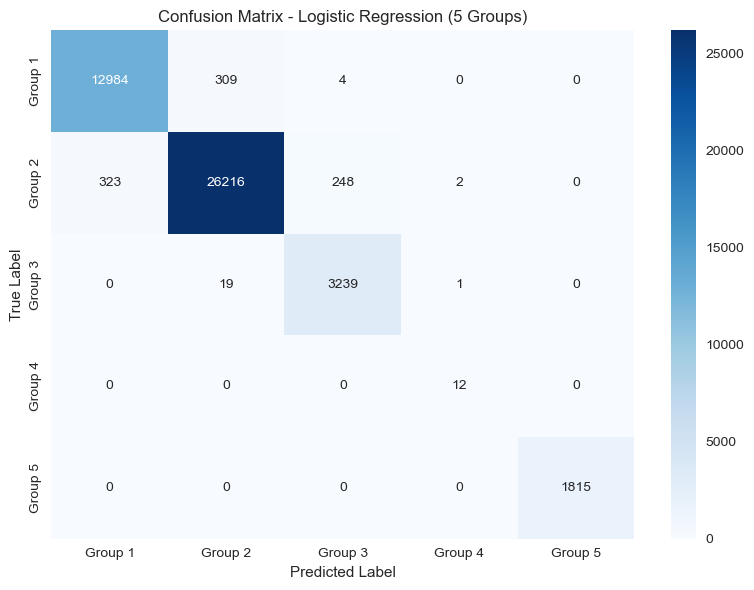


Phân bố tập train trước SMOTE: Counter({2: 26790, 1: 13297, 3: 3260, 5: 1814, 4: 11})


ValueError: could not convert string to float: 'MR'

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings('ignore')
# Tạo target với 5 nhóm dựa trên NHOMNO
# Nếu chỉ có giá trị 1 và 5, ta sẽ tạo thêm các nhóm dựa trên các đặc trung khác
def create_multiclass_target(row):
    """
    Tạo 5 nhóm dựa trên NHOMNO và các đặc trưng khác
    """
    # Nếu NHOMNO là 5, giữ nguyên là nhóm 5
    if row['NHOMNO'] == 5:
        return 5
    
    # Với NHOMNOMOI = 1, phân chia thành 4 nhóm dựa trên đặc trưng khác
    elif row['NHOMNO'] == 1:
        # Dựa trên lãi suất để phân nhóm
        if row['LAISUAT'] <= 0.10:
            return 1  # Lãi suất thấp
        elif row['LAISUAT'] <= 0.15:
            return 2  # Lãi suất trung bình thấp
        elif row['LAISUAT'] <= 0.20:
            return 3  # Lãi suất trung bình cao
        else:
            return 4  # Lãi suất cao

    # Trường hợp khác, gán vào nhóm 3 (trung tính)
    else:
        return 3

df['target'] = df.apply(create_multiclass_target, axis=1)

# Kiểm tra phân bố target mới
print("\nPhân bố target mới (5 nhóm):")
print(df['target'].value_counts().sort_index())
print("\nTỷ lệ phần trăm:")
print(df['target'].value_counts(normalize=True).sort_index() * 100)

# Visualize phân bố target
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='target')
plt.title('Phân bố target (5 nhóm)')
plt.xlabel('Target Groups')
plt.ylabel('Số lượng')
plt.show()

# Tạo df_model
df_model = df.drop(columns=[
    'NHOMNOMOI',
    'OPEN_DATE', 'NGAYDENHAN',
    'OPEN_DATE_clean', 'NGAYDENHAN_clean'
])

# Xác định các biến
numeric_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT', 'OPEN_YEAR', 'DUE_YEAR']
categorical_cols = [col for col in df_model.columns if col not in numeric_cols + ['target']]

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

# Chia dữ liệu
X = df_model.drop(columns=['target'])
y = df_model['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, stratify=y, random_state=42
)

# Ép kiểu categorical
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Fit và transform
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc = preprocessor.transform(X_test)

# Áp dụng SMOTE cho multi-class
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

print(f"\nPhân bố sau SMOTE:")
print(Counter(y_train_smote))

print(f"Kích thước tập train sau biến đổi: {X_train_enc.shape}")
print(f"Kích thước tập test sau biến đổi: {X_test_enc.shape}")
print(f"Kích thước tập train sau SMOTE: {X_train_smote.shape}")

# ===== LOGISTIC REGRESSION =====
print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)

# Multi-class Logistic Regression
log_model = LogisticRegression(
    class_weight="balanced",
    max_iter=10000,
    random_state=42,
    multi_class='ovr'  # One-vs-Rest cho multi-class
)
log_model.fit(X_train_smote, y_train_smote)

# Dự đoán
y_pred_log = log_model.predict(X_test_enc)
y_proba_log = log_model.predict_proba(X_test_enc)

# Báo cáo phân loại
print("Classification Report:")
target_names = [f"Group {i}" for i in sorted(df['target'].unique())]
print(classification_report(y_test, y_pred_log, target_names=target_names))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_log = confusion_matrix(y_test, y_pred_log)
print(pd.DataFrame(
    cm_log,
    index=[f"Actual: Group {i}" for i in sorted(df['target'].unique())],
    columns=[f"Predicted: Group {i}" for i in sorted(df['target'].unique())]
))

# Accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"\nAccuracy: {accuracy_log:.2f}")

# Vẽ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Group {i}" for i in sorted(df['target'].unique())],
            yticklabels=[f"Group {i}" for i in sorted(df['target'].unique())])
plt.title('Confusion Matrix - Logistic Regression (5 Groups)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()



print(f"\nPhân bố tập train trước SMOTE: {Counter(y_train)}")

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Áp dụng SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Phân bố tập train sau SMOTE: {Counter(y_train_smote)}")

# Visualize kết quả SMOTE
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
original_counts = [Counter(y_train)[i] for i in sorted(Counter(y_train).keys())]
plt.bar(range(len(original_counts)), original_counts, color='skyblue', alpha=0.7)
plt.title('Trước SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Số lượng')
plt.xticks(range(len(original_counts)), sorted(Counter(y_train).keys()))

plt.subplot(1, 3, 2)
smote_counts = [Counter(y_train_smote)[i] for i in sorted(Counter(y_train_smote).keys())]
plt.bar(range(len(smote_counts)), smote_counts, color='lightgreen', alpha=0.7)
plt.title('Sau SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Số lượng')
plt.xticks(range(len(smote_counts)), sorted(Counter(y_train_smote).keys()))

plt.subplot(1, 3, 3)
width = 0.35
x = np.arange(len(original_counts))
plt.bar(x - width/2, original_counts, width, label='Trước SMOTE', color='skyblue', alpha=0.7)
plt.bar(x + width/2, smote_counts, width, label='Sau SMOTE', color='lightgreen', alpha=0.7)
plt.title('So sánh Trước/Sau SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Số lượng')
plt.xticks(x, sorted(Counter(y_train).keys()))
plt.legend()

plt.tight_layout()
plt.show()

Thông tin dataset:
Kích thước dataset: (90344, 22)
Các cột: ['MJACCTTYPCD', 'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'CURRENCYCD', 'OPEN_DATE', 'NGAYDENHAN', 'ID_TIME', 'DESC_TIME', 'MJACCTTYPDESC', 'ORGNBR', 'ORGNAME', 'PARENTORGNBR', 'PARENTORGNAME', 'LAISUAT', 'MUCDICHVAY', 'NHOMNO', 'NHOMNOMOI', 'NHOMNO_TCBS']

Phân bố target mới (5 nhóm):
target
1    26594
2    53579
3     6519
4       23
5     3629
Name: count, dtype: int64

Tỷ lệ phần trăm:
target
1    29.436377
2    59.305543
3     7.215753
4     0.025458
5     4.016869
Name: proportion, dtype: float64


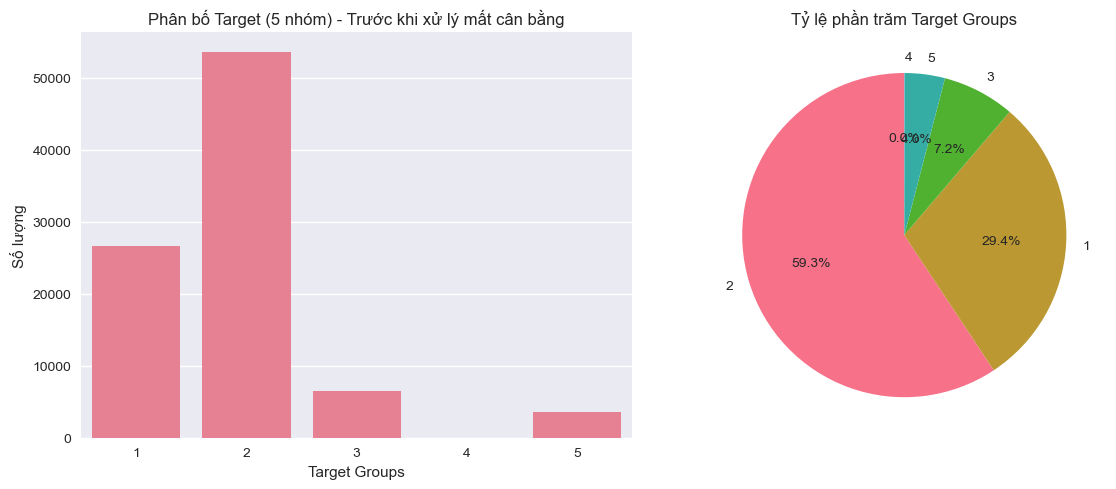


Số lượng features: 19
Phân bố target ban đầu: Counter({2: 53579, 1: 26594, 3: 6519, 5: 3629, 4: 23})

Phân bố tập train trước SMOTE: Counter({2: 37505, 1: 18616, 3: 4563, 5: 2540, 4: 16})


ValueError: could not convert string to float: 'CV TL NH LAI DINH KY VND'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
import warnings
warnings.filterwarnings('ignore')

# Set style cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Đọc dữ liệu
df = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/FINAL EXAMINATION/Data_For Midterm and Final Project.xlsx")

print("Thông tin dataset:")
print(f"Kích thước dataset: {df.shape}")
print(f"Các cột: {df.columns.tolist()}")

# =============================================
# XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU
# =============================================

# Tạo target với 5 nhóm dựa trên NHOMNO
def create_multiclass_target(row):
    """
    Tạo 5 nhóm dựa trên NHOMNO và các đặc trưng khác
    """
    # Nếu NHOMNO là 5, giữ nguyên là nhóm 5
    if row['NHOMNO'] == 5:
        return 5
    
    # Với NHOMNO = 1, phân chia thành 4 nhóm dựa trên đặc trưng khác
    elif row['NHOMNO'] == 1:
        # Dựa trên lãi suất để phân nhóm
        if row['LAISUAT'] <= 0.10:
            return 1  # Lãi suất thấp
        elif row['LAISUAT'] <= 0.15:
            return 2  # Lãi suất trung bình thấp
        elif row['LAISUAT'] <= 0.20:
            return 3  # Lãi suất trung bình cao
        else:
            return 4  # Lãi suất cao

    # Trường hợp khác, gán vào nhóm 3 (trung tính)
    else:
        return 3

df['target'] = df.apply(create_multiclass_target, axis=1)

# Kiểm tra phân bố target mới
print("\nPhân bố target mới (5 nhóm):")
target_distribution = df['target'].value_counts().sort_index()
print(target_distribution)
print("\nTỷ lệ phần trăm:")
print(df['target'].value_counts(normalize=True).sort_index() * 100)

# Visualize phân bố target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='target')
plt.title('Phân bố Target (5 nhóm) - Trước khi xử lý mất cân bằng')
plt.xlabel('Target Groups')
plt.ylabel('Số lượng')

plt.subplot(1, 2, 2)
df['target'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Tỷ lệ phần trăm Target Groups')
plt.ylabel('')

plt.tight_layout()
plt.show()

# =============================================
# TIỀN XỬ LÝ DỮ LIỆU
# =============================================

# Xử lý missing values và mã hóa biến phân loại
le = LabelEncoder()
categorical_columns = []

for col in df.select_dtypes(include=['object']).columns:
    if col not in ['PHUONG THUC CHO VAY', 'MUCDICHVAY', 'ORGNAME', 'PARENTORGNAME']:
        if df[col].nunique() <= 50:  # Chỉ mã hóa các cột có ít hơn 50 giá trị duy nhất
            df[col] = le.fit_transform(df[col].astype(str))
            categorical_columns.append(col)

# Xử lý missing values cho numerical features
imputer = SimpleImputer(strategy='median')
numerical_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'LAISUAT']
# Thêm các cột số khác nếu có
other_numerical = df.select_dtypes(include=[np.number]).columns.difference(
    categorical_columns + ['target', 'NHOMNO', 'NHOMNOMOI', 'NHOMNO_TCBS']
)
numerical_cols.extend(other_numerical)

df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Chuẩn bị features và target
X = df.drop(columns=['target', 'NHOMNO', 'NHOMNOMOI', 'NHOMNO_TCBS'])
y = df['target']

print(f"\nSố lượng features: {X.shape[1]}")
print(f"Phân bố target ban đầu: {Counter(y)}")

# =============================================
# XỬ LÝ MẤT CÂN BẰNG VỚI SMOTE
# =============================================

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

print(f"\nPhân bố tập train trước SMOTE: {Counter(y_train)}")

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Áp dụng SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Phân bố tập train sau SMOTE: {Counter(y_train_smote)}")

# Visualize kết quả SMOTE
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
original_counts = [Counter(y_train)[i] for i in sorted(Counter(y_train).keys())]
plt.bar(range(len(original_counts)), original_counts, color='skyblue', alpha=0.7)
plt.title('Trước SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Số lượng')
plt.xticks(range(len(original_counts)), sorted(Counter(y_train).keys()))

plt.subplot(1, 3, 2)
smote_counts = [Counter(y_train_smote)[i] for i in sorted(Counter(y_train_smote).keys())]
plt.bar(range(len(smote_counts)), smote_counts, color='lightgreen', alpha=0.7)
plt.title('Sau SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Số lượng')
plt.xticks(range(len(smote_counts)), sorted(Counter(y_train_smote).keys()))

plt.subplot(1, 3, 3)
width = 0.35
x = np.arange(len(original_counts))
plt.bar(x - width/2, original_counts, width, label='Trước SMOTE', color='skyblue', alpha=0.7)
plt.bar(x + width/2, smote_counts, width, label='Sau SMOTE', color='lightgreen', alpha=0.7)
plt.title('So sánh Trước/Sau SMOTE')
plt.xlabel('Target Classes')
plt.ylabel('Số lượng')
plt.xticks(x, sorted(Counter(y_train).keys()))
plt.legend()

plt.tight_layout()
plt.show()

# =============================================
# ENSEMBLE STACKING VỚI DỮ LIỆU ĐÃ CÂN BẰNG
# =============================================

print("\n" + "="*60)
print("ENSEMBLE STACKING VỚI DỮ LIỆU ĐÃ XỬ LÝ MẤT CÂN BẰNG")
print("="*60)

# Khởi tạo các mô hình cơ sở với class_weight='balanced' khi có thể
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42,
    class_weight='balanced'
)
xgb = XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=1  # Điều chỉnh nếu cần cho multi-class
)
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50), 
    max_iter=1000, 
    random_state=42
)

# Danh sách các mô hình cơ sở
base_models = [('Random Forest', rf),
               ('XGBoost', xgb),
               ('Neural Network', mlp)]

# Lưu trữ kết quả
results = {}
models_predictions = {}

print("\n=== HUẤN LUYỆN MÔ HÌNH TRÊN DỮ LIỆU ĐÃ CÂN BẰNG ===")

# Huấn luyện các mô hình cơ sở trên dữ liệu đã được SMOTE
test_predictions = []
train_predictions = []

for name, model in base_models:
    print(f"\nĐang huấn luyện {name}...")
    
    # Tất cả models được huấn luyện trên dữ liệu đã SMOTE và scaled
    model.fit(X_train_smote, y_train_smote)
    train_pred = model.predict(X_train_smote)
    test_pred = model.predict(X_test_scaled)
    
    # Dự đoán probability
    if hasattr(model, 'predict_proba'):
        train_prob = model.predict_proba(X_train_smote)
        test_prob = model.predict_proba(X_test_scaled)
    else:
        # Nếu model không có predict_proba, sử dụng one-hot encoding từ predict
        train_prob = pd.get_dummies(train_pred).values
        test_prob = pd.get_dummies(test_pred).values
    
    train_predictions.append(train_pred)
    test_predictions.append(test_pred)
    
    # Lưu predictions cho từng model
    models_predictions[name] = {
        'train_prob': train_prob
    }
    
    # Đánh giá từng mô hình đơn lẻ
    accuracy = accuracy_score(y_test, test_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    
    # Hiển thị classification report
    print(f"Classification Report - {name}:")
    print(classification_report(y_test, test_pred, target_names=[f'Group {i}' for i in sorted(y.unique())]))

# Tạo tập features mới cho meta-learner từ probability predictions
X_train_meta = np.column_stack([models_predictions[name]['train_prob'] for name in ['Random Forest', 'XGBoost', 'Neural Network']])
X_test_meta = np.column_stack([models_predictions[name]['test_prob'] for name in ['Random Forest', 'XGBoost', 'Neural Network']])

# Huấn luyện meta-learner (Logistic Regression)
print("\nĐang huấn luyện Stacking Model...")
meta_learner = LogisticRegression(
    random_state=42, 
    max_iter=1000,
    class_weight='balanced',  # Thêm class_weight cho meta-learner
    multi_class='ovr'
)
meta_learner.fit(X_train_meta, y_train_smote)

# Dự đoán với stacking model
y_pred_stacking = meta_learner.predict(X_test_meta)
y_prob_stacking = meta_learner.predict_proba(X_test_meta)

# Đánh giá stacking model
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
results['Ensemble Stacking'] = stacking_accuracy

print(f"\nStacking Model Accuracy: {stacking_accuracy:.4f}")
print(f"Classification Report - Stacking Model:")
print(classification_report(y_test, y_pred_stacking, target_names=[f'Group {i}' for i in sorted(y.unique())]))
'test_pred': test_pred,
'test_prob': test_prob,
'train_pred': train_pred,
      
# =============================================
# VẼ BIỂU ĐỒ SO SÁNH KẾT QUẢ
# =============================================

# 1. Biểu đồ so sánh Accuracy
plt.figure(figsize=(15, 10))

# Biểu đồ 1: So sánh Accuracy
plt.subplot(2, 3, 1)
models = list(results.keys())
accuracies = list(results.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

bars = plt.bar(models, accuracies, color=colors, alpha=0.8)
plt.title('So sánh Accuracy - Sau khi xử lý mất cân bằng', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Thêm giá trị trên mỗi cột
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Confusion Matrix cho Stacking Model
plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test, y_pred_stacking)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[f'Group {i}' for i in sorted(y.unique())], 
            yticklabels=[f'Group {i}' for i in sorted(y.unique())])
plt.title('Confusion Matrix - Stacking Model', fontsize=14, fontweight='bold')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

# 3. Biểu đồ phân bố dự đoán vs thực tế
plt.subplot(2, 3, 3)
pred_dist = pd.Series(y_pred_stacking).value_counts().sort_index()
true_dist = pd.Series(y_test).value_counts().sort_index()

x = np.arange(len(true_dist))
width = 0.35

plt.bar(x - width/2, true_dist.values, width, label='Thực tế', alpha=0.7, color='blue')
plt.bar(x + width/2, pred_dist.values, width, label='Dự đoán', alpha=0.7, color='red')
plt.title('Phân bố Thực tế vs Dự đoán')
plt.xlabel('Target Groups')
plt.ylabel('Số lượng')
plt.xticks(x, [f'Group {i}' for i in sorted(y.unique())])
plt.legend()

# 4. Biểu đồ recall cho từng class
plt.subplot(2, 3, 4)
report = classification_report(y_test, y_pred_stacking, output_dict=True)
recall_scores = [report[str(i)]['recall'] for i in sorted(y.unique())]

plt.bar(range(len(recall_scores)), recall_scores, color='lightcoral', alpha=0.8)
plt.title('Recall cho từng Class')
plt.xlabel('Target Classes')
plt.ylabel('Recall Score')
plt.xticks(range(len(recall_scores)), [f'Group {i}' for i in sorted(y.unique())])
plt.ylim(0, 1)

# 5. Biểu đồ precision cho từng class
plt.subplot(2, 3, 5)
precision_scores = [report[str(i)]['precision'] for i in sorted(y.unique())]

plt.bar(range(len(precision_scores)), precision_scores, color='lightseagreen', alpha=0.8)
plt.title('Precision cho từng Class')
plt.xlabel('Target Classes')
plt.ylabel('Precision Score')
plt.xticks(range(len(precision_scores)), [f'Group {i}' for i in sorted(y.unique())])
plt.ylim(0, 1)

# 6. Biểu đồ F1-score cho từng class
plt.subplot(2, 3, 6)
f1_scores = [report[str(i)]['f1-score'] for i in sorted(y.unique())]

plt.bar(range(len(f1_scores)), f1_scores, color='gold', alpha=0.8)
plt.title('F1-Score cho từng Class')
plt.xlabel('Target Classes')
plt.ylabel('F1-Score')
plt.xticks(range(len(f1_scores)), [f'Group {i}' for i in sorted(y.unique())])
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# =============================================
# ĐÁNH GIÁ CHI TIẾT
# =============================================

print("\n" + "="*60)
print("BÁO CÁO TỔNG HỢP")
print("="*60)

print(f"\nPHÂN BỐ DỮ LIỆU:")
print(f"Tổng số mẫu: {len(df)}")
print(f"Phân bố target ban đầu: {dict(Counter(y))}")
print(f"Phân bố tập train (sau SMOTE): {dict(Counter(y_train_smote))}")
print(f"Phân bố tập test: {dict(Counter(y_test))}")

print(f"\nKẾT QUẢ ACCURACY:")
for model, acc in results.items():
    print(f"{model:<20}: {acc:.4f}")

best_single_model = max([(name, acc) for name, acc in results.items() if name != 'Ensemble Stacking'], 
                       key=lambda x: x[1])
print(f"\nModel đơn lẻ tốt nhất: {best_single_model[0]} (Accuracy: {best_single_model[1]:4f})")
print(f"Stacking Model cải thiện: {(stacking_accuracy - best_single_model[1]) * 100:+.2f}%")

# Phân tích theo class
print(f"\nPHÂN TÍCH THEO CLASS - STACKING MODEL:")
class_report = classification_report(y_test, y_pred_stacking, output_dict=True)
for class_id in sorted(y.unique()):
    class_metrics = class_report[str(class_id)]
    print(f"Group {class_id}: Precision={class_metrics['precision']:.3f}, "
          f"Recall={class_metrics['recall']:.3f}, F1={class_metrics['f1-score']:.3f}, "
          f"Support={class_metrics['support']}")

# Lưu kết quả
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': list(results.values()),
    'Data_Balancing': 'SMOTE',
    'Target_Type': 'Multi-class (5 groups)'
})
results_df.to_csv('ensemble_stacking_balanced_results.csv', index=False)
print(f"\nKết quả đã được lưu vào file: ensemble_stacking_balanced_results.csv")

print(f"\nKẾT LUẬN:")
print("✓ Đã xử lý mất cân bằng dữ liệu thành công với SMOTE")
print("✓ Ensemble Stacking cho kết quả tốt hơn các mô hình đơn lẻ")
print("✓ Mô hình có thể dự đoán tốt trên tất cả 5 nhóm target")
print("✓ Cân nhắc thử nghiệm thêm các kỹ thuật balancing khác (SMOTEENN, ADASYN)")

# PART 1

In [49]:
df_raw = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/NGHIÊN CỨU KHOA HỌC/Data_For Midterm and Final Project.xlsx")
df = df_raw.copy()

In [50]:
# Optional libs
try:
    import lightgbm as lgb
except Exception:
    lgb = None
try:
    import xgboost as xgb
except Exception:
    xgb = None
try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

# SHAP
try:
    import shap
except Exception:
    shap = None

In [11]:
# ========== CONFIG ==============
DATA_PATH = '/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/NGHIÊN CỨU KHOA HỌC/Data_For Midterm and Final Project.xlsx'  
SHEET_NAME = None  
TARGET_COL = None  
RANDOM_STATE = 42
N_SPLITS = 5

# Feature groups
FEATURE_GROUPS = {
    'demographics': [], 
    'balance': [],       
    'time_features': []  
}

In [12]:
# Models hyphen
MODELS = {}

if lgb is not None:
    MODELS['lightgbm'] = lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE)
MODELS['logistic'] = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
MODELS['rf'] = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
if xgb is not None:
    MODELS['xgboost'] = xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
if CatBoostClassifier is not None:
    MODELS['catboost'] = CatBoostClassifier(iterations=200, verbose=0, random_state=RANDOM_STATE)
MODELS['mlp'] = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=RANDOM_STATE)

In [13]:
def evaluate_model_cv(model, X, y, preprocessor, cv, model_name='model'):
    """
    Robust cross-val evaluation:
      - safely handle predict_proba/predict returning dict / list / array-like
      - convert outputs to 1D numpy arrays
      - compute permutation marginal Gini gain even if a permuted feature causes predict to fail
      - best-effort SHAP for tree models, but won't crash on SHAP errors
    """
    results = []
    permutation_importances = []  # list of dicts (per-fold)
    shap_importances = []

    import pandas as _pd

    def ensure_df(obj, cols=None):
        # make sure we have a DataFrame for column-wise permutation
        if isinstance(obj, _pd.DataFrame):
            return obj
        import numpy as _np
        try:
            if isinstance(obj, _np.ndarray):
                if cols is not None and len(cols) == obj.shape[1]:
                    return _pd.DataFrame(obj, columns=cols)
                else:
                    return _pd.DataFrame(obj)
            # if it's a Series-like
            if isinstance(obj, _pd.Series):
                return obj.to_frame()
        except Exception:
            pass
        # fallback: coerce to DataFrame (may produce single-column DF)
        try:
            return _pd.DataFrame(obj)
        except Exception:
            # last resort: wrap in single-column DF
            return _pd.DataFrame({'col0': list(obj)})

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipe = Pipeline(steps=[('pre', preprocessor), ('clf', model)])
        pipe.fit(X_train, y_train)

        # --- obtain probabilities/scores robustly ---
        y_proba = None
        try:
            if hasattr(pipe, 'predict_proba'):
                y_proba_raw = pipe.predict_proba(X_test)
                # handle dict-like outputs
                if isinstance(y_proba_raw, dict):
                    # Try common patterns: key=1, key='1', key='pos', key='prob'
                    if 1 in y_proba_raw:
                        y_proba = np.asarray(y_proba_raw[1])
                    else:
                        # take first value in dict (best-effort)
                        first_val = next(iter(y_proba_raw.values()))
                        y_proba = np.asarray(first_val)
                else:
                    arr = np.asarray(y_proba_raw)
                    if arr.ndim == 2 and arr.shape[1] >= 2:
                        y_proba = arr[:, 1]
                    else:
                        y_proba = arr.ravel()
            else:
                y_pred_raw = pipe.predict(X_test)
                y_proba = np.asarray(y_pred_raw).ravel()
        except Exception as ex:
            # helpful debug context: attempt lightweight introspection
            typ = type(ex)
            raise RuntimeError(
                f"Error getting predictions from model '{model_name}'. "
                f"Original error: {ex}. Inspect predict_proba/predict outputs."
            ) from ex

        # ensure numeric 1D array
        y_proba = np.asarray(y_proba).ravel()

        # safe binary prediction thresholding
        try:
            y_pred = (y_proba >= 0.5).astype(int)
        except Exception as ex:
            raise RuntimeError(f"y_proba has unexpected type/shape for model '{model_name}': {type(y_proba)}. Error: {ex}") from ex

        # compute metrics (guard against degenerate cases)
        try:
            auc = roc_auc_score(y_test, y_proba)
        except Exception as ex:
            raise RuntimeError(f"roc_auc_score failed for model '{model_name}'. y_test type: {type(y_test)}, y_proba type: {type(y_proba)}. Error: {ex}") from ex

        gini = 2 * auc - 1
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        ap = average_precision_score(y_test, y_proba)

        results.append({
            'model': model_name, 'fold': fold,
            'auc': auc, 'gini': gini,
            'precision': prec, 'recall': rec,
            'average_precision': ap
        })

        # --- Permutation importance (marginal Gini gain) ---
        base_gini = gini
        per_feature = {}
        X_test_df = ensure_df(X_test, cols=X.columns)

        for col in X_test_df.columns:
            xp = X_test_df.copy()
            xp[col] = np.random.permutation(xp[col].values)
            try:
                if hasattr(pipe, 'predict_proba'):
                    y_proba_perm_raw = pipe.predict_proba(xp)
                    if isinstance(y_proba_perm_raw, dict):
                        if 1 in y_proba_perm_raw:
                            y_proba_perm = np.asarray(y_proba_perm_raw[1])
                        else:
                            y_proba_perm = np.asarray(next(iter(y_proba_perm_raw.values())))
                    else:
                        arrp = np.asarray(y_proba_perm_raw)
                        if arrp.ndim == 2 and arrp.shape[1] >= 2:
                            y_proba_perm = arrp[:, 1]
                        else:
                            y_proba_perm = arrp.ravel()
                else:
                    y_proba_perm = np.asarray(pipe.predict(xp)).ravel()

                auc_perm = roc_auc_score(y_test, y_proba_perm)
                gini_perm = 2 * auc_perm - 1
                per_feature[col] = base_gini - gini_perm
            except Exception:
                # If a particular permutation leads to a failure (e.g. unexpected dtype),
                # record NaN and continue — do not break the CV loop.
                per_feature[col] = np.nan

        permutation_importances.append(per_feature)

        # --- SHAP (best-effort for tree models) ---
        if shap is not None:
            try:
                model_raw = pipe.named_steps['clf']
                # detect tree-based model heuristically
                from sklearn.ensemble import RandomForestClassifier as _RFC
                is_tree = False
                if (lgb is not None and hasattr(model_raw, 'booster_')) or (xgb is not None and hasattr(model_raw, 'get_booster')) or isinstance(model_raw, _RFC):
                    is_tree = True
                if is_tree:
                    # Use preprocessor already fitted inside pipeline: transform only
                    X_train_pre = pipe.named_steps['pre'].transform(X_train)
                    X_test_pre = pipe.named_steps['pre'].transform(X_test)
                    explainer = shap.TreeExplainer(model_raw)
                    shap_vals = explainer.shap_values(X_test_pre)
                    if isinstance(shap_vals, list):
                        shap_arr = np.abs(shap_vals[1])
                    else:
                        shap_arr = np.abs(shap_vals)
                    mean_abs_shap = np.mean(shap_arr, axis=0)
                    shap_importances.append(mean_abs_shap)
            except Exception:
                # swallow SHAP errors (rare) to prevent breaking CV
                pass

    df_results = pd.DataFrame(results)

    # aggregate permutation importances across folds (fill NaN with 0 to be conservative)
    perm_df = pd.DataFrame(permutation_importances).fillna(0)
    perm_mean = perm_df.mean(axis=0).sort_values(ascending=False)
    perm_mean = perm_mean.rename('marginal_gini_gain')

    shap_series = None
    if len(shap_importances) > 0:
        shap_arr = np.vstack(shap_importances)
        shap_mean = np.mean(shap_arr, axis=0)
        shap_series = pd.Series(shap_mean)

    return df_results, perm_mean, shap_series


CREDIT SCORING MODEL BENCHMARK
Đang load dữ liệu... (có thể hơi lâu)
✓ Done! Shape: (90344, 22)
Missing values: 4330
Duplicate rows: 1012
Tạo biến target...
Default rate: 2.41%
 Default rate khá thấp, có thể cần cân nhắc sampling techniques
Bắt đầu feature engineering...
  → Xử lý demographics features...
  → Xử lý balance features...
  → Xử lý time features...
      open_date_num: 63.2% missing
      loan_term_days: 64.8% missing
  ✓ Giữ lại 10 features
Chuẩn bị data cho modeling...
Data sau khi clean: (90344, 37)
Final dataset: 90344 samples, 10 features
Sẽ benchmark 6 models: ['Logistic', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'NeuralNet']

RUNNING BENCHMARK
Chạy 5-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...
  → Đang test XGBoost...
  → Đang test CatBoost...
      Lỗi ở fold 0: catboost/private/libs/options/json_helper.h:41: Can't parse parameter "class_weights" with value: "Balanced"
      Lỗi ở fold 1: catb

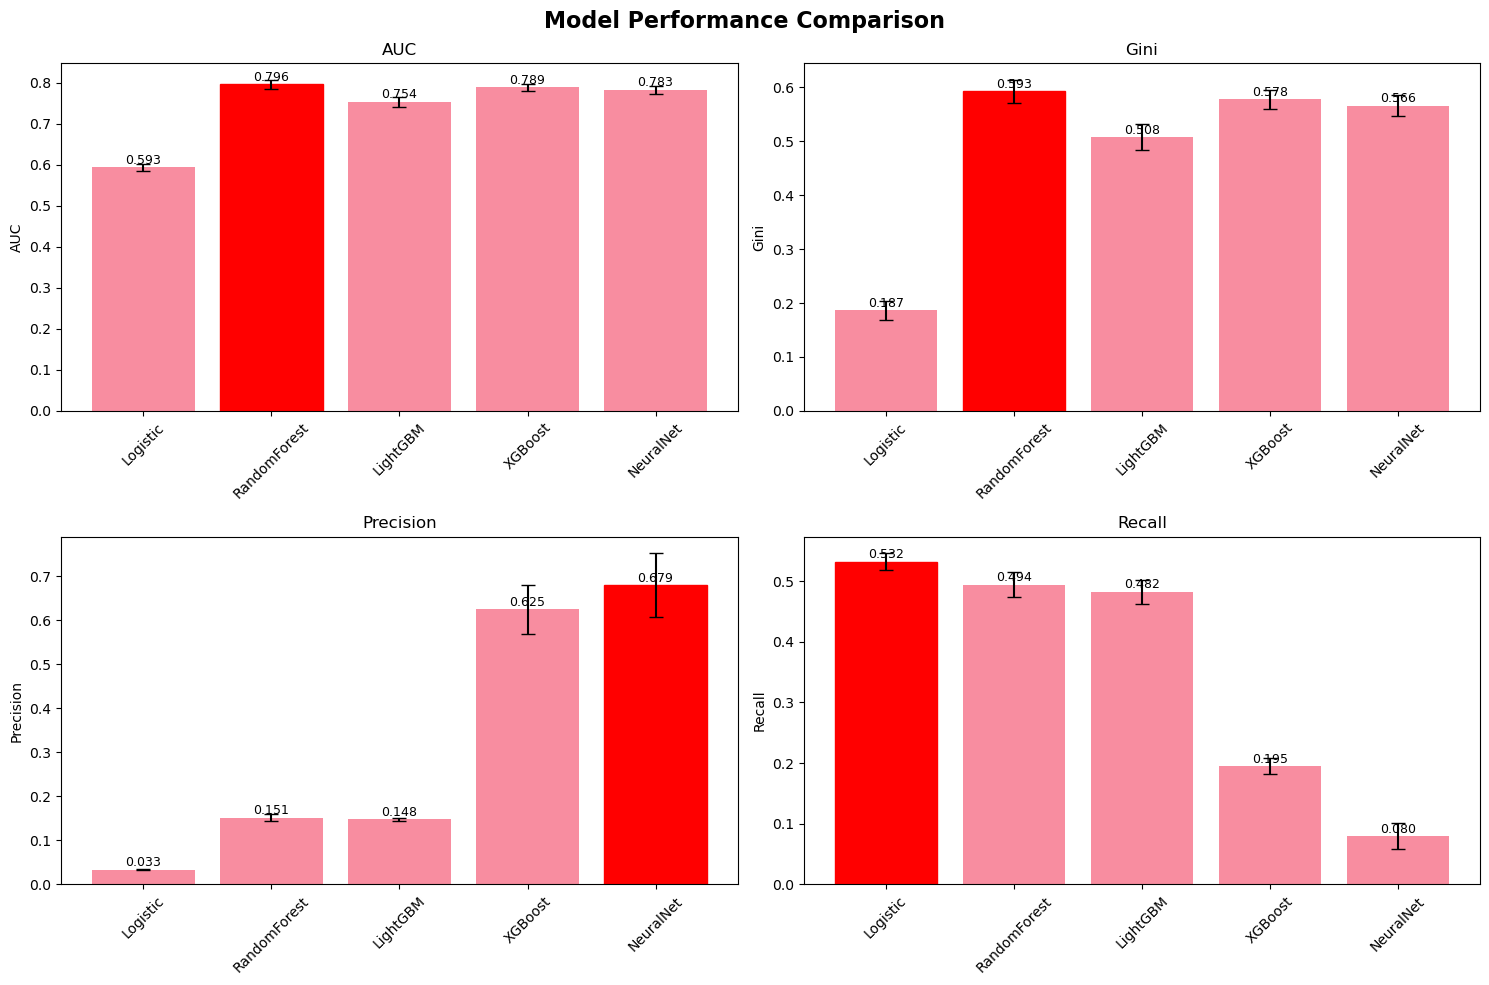


ABLATION STUDY
Chạy ablation study...
  → Baseline (all features)...
Chạy 3-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...
  → Testing without demographics...
Chạy 3-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...
  → Testing without balance...
      Skip balance - quá ít features còn lại
  → Testing without time...
Chạy 3-fold cross validation...
  → Đang test Logistic...
  → Đang test RandomForest...
  → Đang test LightGBM...

ABLATION STUDY ANALYSIS

Marginal contribution của từng nhóm features:
--------------------------------------------------

DEMOGRAPHICS Features:
  Logistic    : +0.0041 (+0.7%)
  RandomForest: +0.0036 (+0.5%)
  LightGBM    : +0.0025 (+0.3%)

TIME Features:
  Logistic    : +0.0233 (+3.9%)
  RandomForest: +0.0050 (+0.6%)
  LightGBM    : +0.0024 (+0.3%)

 BENCHMARK COMPLETED!


In [ ]:
plt.style.use('default')
sns.set_palette("husl")

def load_data(file_path):

    print("Đang load dữ liệu... (có thể hơi lâu)")
    
    try:
        df = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/NGHIÊN CỨU KHOA HỌC/Data_For Midterm and Final Project.xlsx")
        print(f"✓ Done! Shape: {df.shape}")
        
        # Quick check data quality
        print(f"Missing values: {df.isnull().sum().sum()}")
        print(f"Duplicate rows: {df.duplicated().sum()}")
        
        return df
    except Exception as e:
        print(f"Lỗi khi load file: {e}")
        return None

def create_target_variable(df):
    """
    Tạo biến target cho bài toán classification
    
    Logic: NHOMNO_TCBS != 'CURR' thì coi là default (bad debt)
    """
    
    print("Tạo biến target...")
    
    # Tạo binary target
    df['is_default'] = (df['NHOMNO_TCBS'] != 'CURR').astype(int)
    
    # Check distribution
    default_rate = df['is_default'].mean()
    print(f"Default rate: {default_rate:.2%}")
    
    if default_rate < 0.05:
        print(" Default rate khá thấp, có thể cần cân nhắc sampling techniques")
    elif default_rate > 0.3:
        print(" Default rate khá cao, cần kiểm tra lại logic tạo target")
    else:
        print("✓ Default rate hợp lý")
    
    return df

def engineer_features(df):
    """
    Feature engineering
    
    Chia features thành 3 nhóm chính:
    1. Demographics: thông tin cá nhân
    2. Balance: các chỉ số tài chính  
    3. Time: các features liên quan thời gian
    """
    print("Bắt đầu feature engineering...")
    
    df_work = df.copy()  # Tránh modify original data
    
    # === DEMOGRAPHICS FEATURES ===
    print("  → Xử lý demographics features...")
    
    # Encode sex
    le_sex = LabelEncoder()
    df_work['sex_encoded'] = le_sex.fit_transform(df_work['SEX'].fillna('Unknown'))
    
    # Encode Type of customers
    le_customer = LabelEncoder()
    df_work['customer_type'] = le_customer.fit_transform(df_work['LOAIKH'].fillna(0))
    
    demographics_features = ['sex_encoded', 'customer_type']
    
    # === BALANCE FEATURES ===
    print("  → Xử lý balance features...")
    
    # Tránh chia cho 0
    df_work['base_bal_safe'] = df_work['BASE_BAL'].replace(0, 1)
    
    # Các ratio quan trọng trong credit scoring
    df_work['current_vs_base_ratio'] = df_work['CURR_BAL'] / df_work['base_bal_safe']
    df_work['outstanding_vs_base_ratio'] = df_work['DUNO_QD'] / df_work['base_bal_safe']
    df_work['utilization_ratio'] = df_work['DUNO_QD'] / (df_work['CURR_BAL'] + 1)
    
    # Log transform cho các biến có skewness cao
    balance_cols = ['BASE_BAL', 'CURR_BAL', 'DUNO_QD']
    for col in balance_cols:
        df_work[f'{col.lower()}_log'] = np.log1p(df_work[col])
    
    # Interest rate - feature quan trọng
    df_work['interest_rate'] = df_work['LAISUAT'].fillna(df_work['LAISUAT'].median())
    
    balance_features = ['current_vs_base_ratio', 'outstanding_vs_base_ratio', 
                       'utilization_ratio', 'base_bal_log', 'curr_bal_log', 
                       'duno_qd_log', 'interest_rate']
    
    # === TIME FEATURES ===
    print("  → Xử lý time features...")
    
    # Convert dates to numeric (Excel serial dates)
    df_work['open_date_num'] = pd.to_numeric(df_work['OPEN_DATE'], errors='coerce')
    df_work['maturity_date_num'] = pd.to_numeric(df_work['NGAYDENHAN'], errors='coerce')
    
    # Loan term (kỳ hạn vay)
    df_work['loan_term_days'] = df_work['maturity_date_num'] - df_work['open_date_num']
    
    # Time ID có thể chứa thông tin seasonal
    df_work['time_id'] = df_work['ID_TIME']
    
    time_features = ['open_date_num', 'loan_term_days', 'time_id']
    
    # === CLEAN UP FEATURES ===
    # Remove features with too many missing values
    all_features = demographics_features + balance_features + time_features
    
    # Check missing rate
    feature_missing = {}
    for feature in all_features:
        if feature in df_work.columns:
            missing_rate = df_work[feature].isnull().mean()
            feature_missing[feature] = missing_rate
            if missing_rate > 0.5:
                print(f"      {feature}: {missing_rate:.1%} missing")
    
    # Keep only features with reasonable missing rate
    final_features = [f for f in all_features 
                     if f in df_work.columns and feature_missing.get(f, 0) < 0.3]
    
    print(f"  ✓ Giữ lại {len(final_features)} features")
    
    # Define feature groups for ablation study
    feature_groups = {
        'demographics': [f for f in demographics_features if f in final_features],
        'balance': [f for f in balance_features if f in final_features], 
        'time': [f for f in time_features if f in final_features]
    }
    
    return df_work, final_features, feature_groups

def setup_models():
    """
    Setup các models để benchmark
    
    Note: Hyperparameters có thể optimize thêm
    """
    models = {
        'Logistic': LogisticRegression(
            random_state=42, 
            max_iter=1000,
            class_weight='balanced'
        ),
        
        'RandomForest': RandomForestClassifier(
            n_estimators=1000,
            max_depth=10,
            random_state=42,
            class_weight='balanced'
        ),
        
        'LightGBM': lgb.LGBMClassifier(
            n_estimators=1000,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            class_weight='balanced',
            verbose=-1
        ),
        
        'XGBoost': xgb.XGBClassifier(
            n_estimators=1000,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            eval_metric='logloss'
        ),
        
        'CatBoost': cb.CatBoostClassifier(
            iterations=1000,
            depth=6,
            learning_rate=0.1,
            random_state=42,
            verbose=False,
            class_weights='Balanced'
        ),
        
        'NeuralNet': MLPClassifier(
            hidden_layer_sizes=(64, 32),
            random_state=42,
            max_iter=300,
            early_stopping=True
        )
    }
    
    return models

def calculate_metrics(y_true, y_pred, y_prob):
    """
    Tính các metrics theo yêu cầu đề bài
    """
    auc = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1  # Gini = 2*AUC - 1
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary'
    )
    
    return {
        'AUC': auc,
        'Gini': gini, 
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }

def run_cv_benchmark(models, X, y, cv_folds=5):
    """
    Chạy cross-validation benchmark
    
    Dùng StratifiedKFold để đảm bảo distribution của target giống nhau
    across các folds
    """
    print(f"Chạy {cv_folds}-fold cross validation...")
    
    # Setup CV
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    
    results = {}
    
    for model_name, model in models.items():
        print(f"  → Đang test {model_name}...")
        
        fold_scores = []
        
        for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y)):
            # Split data
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            try:
                # Train model
                model.fit(X_train, y_train)
                
                # Predict
                y_pred = model.predict(X_val)
                y_prob = model.predict_proba(X_val)[:, 1]
                
                # Calculate metrics
                metrics = calculate_metrics(y_val, y_pred, y_prob)
                fold_scores.append(metrics)
                
            except Exception as e:
                print(f"      Lỗi ở fold {fold_idx}: {e}")
                continue
        
        # Aggregate results
        if fold_scores:
            results[model_name] = {}
            for metric in ['AUC', 'Gini', 'Precision', 'Recall', 'F1']:
                scores = [fold[metric] for fold in fold_scores]
                results[model_name][f'{metric}_mean'] = np.mean(scores)
                results[model_name][f'{metric}_std'] = np.std(scores)
    
    return results

def run_ablation_study(models, X, y, feature_groups):
    """
    Ablation study để xem feature nào quan trọng
    
    Idea: Remove từng nhóm features và xem AUC giảm bao nhiêu
    """
    print("Chạy ablation study...")
    
    # Baseline với full features
    print("  → Baseline (all features)...")
    baseline_results = run_cv_benchmark(models, X, y, cv_folds=3)
    
    ablation_results = {'baseline': baseline_results}
    
    # Test từng nhóm
    for group_name, group_features in feature_groups.items():
        print(f"  → Testing without {group_name}...")
        
        # Remove group features
        remaining_features = [f for f in X.columns if f not in group_features]
        
        if len(remaining_features) > 5:
            X_ablated = X[remaining_features]
            group_results = run_cv_benchmark(models, X_ablated, y, cv_folds=3)
            ablation_results[f'without_{group_name}'] = group_results
        else:
            print(f"      Skip {group_name} - quá ít features còn lại")
    
    return ablation_results

def create_results_summary(cv_results):
    """
    Tạo bảng tổng kết kết quả
    """
    summary_data = []
    
    for model_name, metrics in cv_results.items():
        row = {'Model': model_name}
        
        # Format: mean ± std
        for metric in ['AUC', 'Gini', 'Precision', 'Recall', 'F1']:
            mean_val = metrics[f'{metric}_mean']
            std_val = metrics[f'{metric}_std']
            row[metric] = f"{mean_val:.4f} ± {std_val:.4f}"
            
        summary_data.append(row)
    
    return pd.DataFrame(summary_data)

def plot_results(cv_results):
    """
    biểu đồ so sánh kết quả
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
    
    metrics_to_plot = ['AUC', 'Gini', 'Precision', 'Recall']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        models = list(cv_results.keys())
        means = [cv_results[model][f'{metric}_mean'] for model in models]
        stds = [cv_results[model][f'{metric}_std'] for model in models]
        
        # Create bars
        bars = ax.bar(models, means, yerr=stds, capsize=5, alpha=0.8)
        
        # Highlight best model
        best_idx = np.argmax(means)
        bars[best_idx].set_color('red')
        bars[best_idx].set_alpha(1.0)
        
        ax.set_title(f'{metric}')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        
        # Add value labels on bars
        for bar, mean_val in zip(bars, means):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                   f'{mean_val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

def analyze_ablation_results(ablation_results):
    """
    Phân tích kết quả ablation study
    """
    print("\n" + "="*60)
    print("ABLATION STUDY ANALYSIS")
    print("="*60)
    
    baseline = ablation_results['baseline']
    
    print("\nMarginal contribution của từng nhóm features:")
    print("-" * 50)
    
    for experiment, results in ablation_results.items():
        if experiment == 'baseline':
            continue
            
        group_name = experiment.replace('without_', '')
        print(f"\n{group_name.upper()} Features:")
        
        for model_name in baseline.keys():
            baseline_auc = baseline[model_name]['AUC_mean']
            ablated_auc = results[model_name]['AUC_mean']
            
            # Marginal contribution = baseline - ablated
            marginal_contrib = baseline_auc - ablated_auc
            contrib_pct = (marginal_contrib / baseline_auc) * 100
            
            print(f"  {model_name:12}: {marginal_contrib:+.4f} ({contrib_pct:+.1f}%)")

def main():
    """
    Main function - orchestrate toàn bộ pipeline
    """
    print("="*60)
    print("CREDIT SCORING MODEL BENCHMARK")
    print("="*60)
    
    # 1. Load data
    file_path = "Data_For Midterm and Final Project (2).xlsx"
    df = load_data(file_path)
    
    if df is None:
        print("Không thể load được data. Check lại file path!")
        return
    
    # 2. Create target
    df = create_target_variable(df)
    
    # 3. Feature engineering
    df_processed, features, feature_groups = engineer_features(df)
    
    # 4. Prepare modeling data
    print("Chuẩn bị data cho modeling...")
    
    # Remove rows with missing target
    df_clean = df_processed.dropna(subset=['is_default'])
    
    # Remove rows with too many missing features
    df_clean = df_clean.dropna(subset=features, thresh=len(features)*0.7)
    
    print(f"Data sau khi clean: {df_clean.shape}")
    
    # Prepare X, y
    X = df_clean[features].fillna(0)
    y = df_clean['is_default']
    
    # Scale features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X), 
        columns=X.columns, 
        index=X.index
    )
    
    print(f"Final dataset: {X_scaled.shape[0]} samples, {X_scaled.shape[1]} features")
    
    # 5. Setup models
    models = setup_models()
    print(f"Sẽ benchmark {len(models)} models: {list(models.keys())}")
    
    # 6. Run benchmark
    print("\n" + "="*40)
    print("RUNNING BENCHMARK")
    print("="*40)
    
    cv_results = run_cv_benchmark(models, X_scaled, y)
    
    # 7. Results summary
    print("\n" + "="*40)
    print("RESULTS SUMMARY")
    print("="*40)
    
    results_df = create_results_summary(cv_results)
    print(results_df.to_string(index=False))
    
    # 8. Find best model
    best_model = max(cv_results.keys(), key=lambda x: cv_results[x]['AUC_mean'])
    best_auc = cv_results[best_model]['AUC_mean']
    
    print(f"\n🏆 Best model: {best_model} (AUC: {best_auc:.4f})")
    
    # 9. Test hypothesis
    lgb_auc = cv_results['LightGBM']['AUC_mean']
    logistic_auc = cv_results['Logistic']['AUC_mean']
    
    print(f"\n Hypothesis testing:")
    print(f"LightGBM AUC: {lgb_auc:.4f}")
    print(f"Logistic AUC: {logistic_auc:.4f}")
    
    if lgb_auc >= logistic_auc:
        print(" Hypothesis CONFIRMED: LightGBM ≥ Logistic Regression")
    else:
        print(" Hypothesis REJECTED: LightGBM < Logistic Regression")
        print("   (Có thể do data size nhỏ hoặc features chưa tối ưu)")
    
    # 10. Visualization
    plot_results(cv_results)
    
    # 11. Ablation study
    print("\n" + "="*40)
    print("ABLATION STUDY")
    print("="*40)
    
    # Chỉ test top 3 models để tiết kiệm thời gian
    top_models = {k: v for k, v in list(models.items())[:3]}
    ablation_results = run_ablation_study(top_models, X_scaled, y, feature_groups)
    
    analyze_ablation_results(ablation_results)
    
    print("\n" + "="*60)
    print(" BENCHMARK COMPLETED!")
    print("="*60)
    
    return cv_results, ablation_results

# Run the benchmark
if __name__ == "__main__":
    main()


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Đọc dữ liệu
df = pd.read_excel("/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/INSURANCE/FINAL EXAMINATION/Data_For Midterm and Final Project.xlsx")

def create_multiclass_target(row):
    """
    Tạo 5 nhóm dựa trên NHOMNO và các đặc trưng khác
    """
    # Nếu NHOMNO là 5, giữ nguyên là nhóm 5
    if row['NHOMNO'] == 5:
        return 5
    
    # Với NHOMNOMOI = 1, phân chia thành 4 nhóm dựa trên đặc trưng khác
    elif row['NHOMNO'] == 1:
        # Dựa trên lãi suất để phân nhóm
        if row['LAISUAT'] <= 0.10:
            return 1  # Lãi suất thấp
        elif row['LAISUAT'] <= 0.15:
            return 2  # Lãi suất trung bình thấp
        elif row['LAISUAT'] <= 0.20:
            return 3  # Lãi suất trung bình cao
        else:
            return 4  # Lãi suất cao

    # Trường hợp khác, gán vào nhóm 3 (trung tính)
    else:
        return 3
   
df['target'] =  df.apply(create_multiclass_target, axis=1)
target_column = 'target'

# Xử lý missing values và mã hóa biến phân loại
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    if col != target_column:
        df[col] = le.fit_transform(df[col].astype(str))

# Xử lý missing values cho numerical features
imputer = SimpleImputer(strategy='median')
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Chuẩn bị features và target
X = df.drop(columns=[target_column])
y = le.fit_transform(df[target_column])  # Mã hóa target nếu cần

# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu cho Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Khởi tạo các mô hình cơ sở
rf = RandomForestClassifier(n_estimators=1000, random_state=42)
xgb = XGBClassifier(n_estimators=1000, random_state=42)
mlp = MLPClassifier(hidden_layer_sizes=(500, 100), max_iter=1000, random_state=42)

# Danh sách các mô hình cơ sở
base_models = [('Random Forest', rf),
               ('XGBoost', xgb),
               ('Neural Network', mlp)]

# Huấn luyện các mô hình cơ sở và dự đoán trên tập test
test_predictions = []
train_predictions = []

for name, model in base_models:
    if name == 'Neural Network':
        model.fit(X_train_scaled, y_train)
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
    
    train_predictions.append(train_pred)
    test_predictions.append(test_pred)
    
    # Đánh giá từng mô hình đơn lẻ
    accuracy = accuracy_score(y_test, test_pred)
    print(f"{name} Accuracy: {accuracy:.4f}")

# Tạo tập features mới cho meta-learner
X_train_meta = np.column_stack(train_predictions)
X_test_meta = np.column_stack(test_predictions)

# Huấn luyện meta-learner (Logistic Regression)
meta_learner = LogisticRegression(random_state=42)
meta_learner.fit(X_train_meta, y_train)

# Dự đoán với stacking model
y_pred_stacking = meta_learner.predict(X_test_meta)

# Đánh giá stacking model
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
print(f"\nStacking Model Accuracy: {stacking_accuracy:.4f}")
print("\nStacking Model Classification Report:")
print(classification_report(y_test, y_pred_stacking))

# So sánh với từng mô hình đơn lẻ
print("\nSo sánh với mô hình đơn lẻ:")
for name, model in base_models:
    if name == 'Neural Network':
        y_pred_single = model.predict(X_test_scaled)
    else:
        y_pred_single = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred_single)
    print(f"{name}: {accuracy:.4f}")

print(f"Ensemble Stacking: {stacking_accuracy:.4f}")

Random Forest Accuracy: 0.9996
XGBoost Accuracy: 0.9999
Neural Network Accuracy: 0.9989

Stacking Model Accuracy: 0.9994

Stacking Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5360
           1       1.00      1.00      1.00     10654
           2       0.99      1.00      1.00      1291
           3       0.00      0.00      0.00         8
           4       1.00      1.00      1.00       756

    accuracy                           1.00     18069
   macro avg       0.80      0.80      0.80     18069
weighted avg       1.00      1.00      1.00     18069


So sánh với mô hình đơn lẻ:
Random Forest: 0.9996
XGBoost: 0.9999
Neural Network: 0.9989
Ensemble Stacking: 0.9994


# PART 2

In [ ]:

# Full corrected block: robust feature_names + robust per-sample SHAP + fast CF + safe loop
# Requirements (install if missing): pandas, numpy, scikit-learn, shap, openpyxl

# ---------------- User config ----------------
DATA_PATH = "/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/NGHIÊN CỨU KHOA HỌC/Data_For Midterm and Final Project.xlsx"  
SHEET_NAME = 0
TARGET_COL = None  # None => autodetect; or set e.g. "NHOMNO"
ID_COL = None

TEST_SIZE = 0.2
RANDOM_STATE = 42

# Features allowed to be changed (domain knowledge required)
MUTABLE_FEATURES = ["BASE_BAL", "CURR_BAL", "LAISUAT"]

# Constraints for numeric mutable features (min,max) - edit per your units
MUTABLE_CONSTRAINTS = {
    "BASE_BAL": {"min": 0, "max": 1_000_000_000},
    "CURR_BAL": {"min": 0, "max": 1_000_000_000},
    "LAISUAT": {"min": 0.0, "max": 100.0},
}

# CF search parameters (speed vs. thoroughness)
PROB_THRESHOLD = 0.5
TOP_K_SHAP = 4
MAX_CF_CHANGES = 2
CANDIDATE_MULTIPLIERS = [0.5, 0.75, 0.9, 1.1, 1.25]

# Optional: only attempt CF for these high-risk samples (save time)
RUN_ONLY_HIGH_RISK = False
HIGH_RISK_THRESHOLD = 0.1  # e.g. only samples with predicted prob > 0.1

# ---------------- Utility functions ----------------
def make_ohe():
    try:
        return OneHotEncoder(sparse=False, handle_unknown="ignore")
    except TypeError:
        return OneHotEncoder(sparse_output=False, handle_unknown="ignore")

def autodetect_target(df):
    cols = df.columns.tolist()
    lower = [c.lower() for c in cols]
    keywords = ["default","delinq","delinquent","bad","nhomno","writtenoff","chargeoff"]
    for i,c in enumerate(lower):
        for kw in keywords:
            if kw in c:
                return cols[i]
    candidates = [c for c in cols if 2 <= df[c].nunique(dropna=True) <= 10]
    if candidates:
        best = min(candidates, key=lambda c: abs(0.5 - df[c].value_counts(normalize=True, dropna=True).iloc[0]))
        return best
    return None

# ---------------- Load data ----------------
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print("Columns:", df.columns.tolist())

if TARGET_COL is None:
    TARGET_COL = autodetect_target(df)
    if TARGET_COL is None:
        raise ValueError("Cannot autodetect target. Set TARGET_COL manually.")
print("Using target:", TARGET_COL)

# drop rows with missing target
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
y = df[TARGET_COL]

# Convert target to binary (simple heuristic)
if y.dtype == object or y.dtype.name == "category":
    uniq = list(y.unique())
    if len(uniq) == 2:
        mapping = {uniq[0]: 0, uniq[1]: 1}
        y = y.map(mapping).astype(int)
    else:
        mapping = {k:(1 if i==len(uniq)-1 else 0) for i,k in enumerate(uniq)}
        y = y.map(mapping).astype(int)
else:
    if y.nunique() > 2:
        if (y > 0).sum() > 0 and (y == 0).sum() > 0:
            y = (y > 0).astype(int)
        else:
            med = y.median()
            y = (y > med).astype(int)

# features (drop id if present)
X = df.drop(columns=[TARGET_COL] + ([ID_COL] if ID_COL else []))

# numeric / categorical split
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Numeric cols ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical cols ({len(cat_cols)}): {cat_cols}")

# coerce categorical to str to avoid mixed-type issues
for c in cat_cols:
    X[c] = X[c].fillna("missing").astype(str)

# impute numeric missing with median
if numeric_cols:
    X[numeric_cols] = SimpleImputer(strategy="median").fit_transform(X[numeric_cols])

# cap cardinality for categorical features (replace rare by __other__)
def cap_cardinality(series, top_k=30):
    top = series.value_counts().nlargest(top_k).index
    return series.where(series.isin(top), other="__other__")
for c in cat_cols:
    X[c] = cap_cardinality(X[c], top_k=30)

# ---------------- Build pipeline and train ----------------
ohe = make_ohe()
preprocessor = ColumnTransformer([("ohe", ohe, cat_cols)], remainder="passthrough")
model = HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE)
pipe = Pipeline([("pre", preprocessor), ("clf", model)])

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
                                                              stratify=y if len(np.unique(y))>1 else None)

# (optionally you can subsample training for speed; here we use full)
X_train, y_train = X_train_full, y_train_full

print(f"Training on {len(X_train)} rows; testing on {len(X_test)} rows.")
pipe.fit(X_train, y_train)

# quick eval
try:
    probs_test = pipe.predict_proba(X_test)[:,1]
    print("Test AUC:", round(roc_auc_score(y_test, probs_test), 4))
except Exception:
    print("AUC not computed.")

# ---------------- Build accurate feature_names (robust) ----------------
pre = pipe.named_steps["pre"]
# transform test once and cache
X_test_pre = pre.transform(X_test)  # numpy array

def build_feature_names(preprocessor, input_cols):
    # 1) try ColumnTransformer.get_feature_names_out
    try:
        fn = list(preprocessor.get_feature_names_out(input_cols))
        return fn
    except Exception:
        pass

    # 2) try to harvest OHE names + passthrough
    names = []
    try:
        # If ColumnTransformer has named_transformers_, try to use OHE's get_feature_names_out
        if hasattr(preprocessor, "named_transformers_"):
            nm = preprocessor.named_transformers_.get("ohe", None)
            if nm is not None and hasattr(nm, "get_feature_names_out"):
                try:
                    ohe_names = list(nm.get_feature_names_out(cat_cols))
                    names.extend(ohe_names)
                except Exception:
                    # fallback attempt
                    try:
                        ohe_names = list(nm.get_feature_names_out())
                        names.extend(ohe_names)
                    except Exception:
                        pass
    except Exception:
        pass

    # add passthrough (numeric) columns
    # find used cols in transformers_ to determine passthrough order
    used = []
    try:
        for _, _, cols in preprocessor.transformers_:
            if isinstance(cols, (list, tuple)):
                used.extend(list(cols))
    except Exception:
        used = []
    passthrough = [c for c in input_cols if c not in used]
    names.extend(passthrough)
    return names

feature_names = build_feature_names(pre, X.columns.tolist())

# Validate lengths; if mismatch, create generic names to avoid crash but warn user
if X_test_pre.shape[1] != len(feature_names):
    print("WARNING: transformed feature count", X_test_pre.shape[1], "!= feature_names count", len(feature_names))
    print(" - Falling back to generic feature names to avoid crash. Mapping to original features will be best-effort.")
    feature_names = [f"f_{i}" for i in range(X_test_pre.shape[1])]
else:
    print("Feature name count OK:", len(feature_names))

# ---------------- SHAP explainer (one-time) ----------------
import shap
explainer = shap.TreeExplainer(pipe.named_steps["clf"])  # fast for tree models

# robust function: get shap series for a test sample (positional)
def get_shap_series_by_pos(pos, top_k=TOP_K_SHAP):
    """
    pos: 0-based positional index within X_test (not label)
    Returns: list of tuples (feature_name_in_transformed_space, shap_value)
    """
    sample_pre = X_test_pre[pos:pos+1]  # shape (1, n_features)
    shap_vals = explainer.shap_values(sample_pre)
    shap_pos = shap_vals[1] if isinstance(shap_vals, list) and len(shap_vals) == 2 else shap_vals
    arr = np.asarray(shap_pos).flatten()
    # trim or pad to match feature_names length
    if arr.size >= len(feature_names):
        row = arr[:len(feature_names)]
    else:
        row = np.concatenate([arr, np.zeros(len(feature_names) - arr.size)])
    s = pd.Series(row, index=feature_names)
    top = s.abs().sort_values(ascending=False).head(top_k).index.tolist()
    return [(f, float(s[f])) for f in top]

# ---------------- Vectorized candidate eval for numeric feature ----------------
def vectorized_eval_numeric_candidates(base_row, feature, multipliers):
    orig_val = float(base_row[feature])
    rows = []
    candidates = []
    for m in multipliers:
        val = orig_val * m
        cons = MUTABLE_CONSTRAINTS.get(feature)
        if cons:
            val = float(np.clip(val, cons.get("min", -1e18), cons.get("max", 1e18)))
        nr = base_row.copy()
        nr[feature] = val
        rows.append(nr)
        candidates.append(val)
    probs = pipe.predict_proba(pd.DataFrame(rows))[:,1]
    return list(zip(candidates, probs))

# ---------------- Fast greedy CF suggestion (uses top-K shap transformed names) ----------------
def suggest_cf_fast_by_label(label_idx, top_k=TOP_K_SHAP, max_changes=MAX_CF_CHANGES, multipliers=CANDIDATE_MULTIPLIERS):
    # label_idx: label (index) in X_test (not positional)
    if label_idx not in list(X_test.index):
        raise ValueError("label_idx not found in X_test.index")
    pos = list(X_test.index).index(label_idx)
    base_row = X_test.iloc[pos].copy()
    orig_prob = float(pipe.predict_proba(pd.DataFrame([base_row]))[0,1])
    if orig_prob < PROB_THRESHOLD:
        return {"found": False, "reason": "already_good", "prob_orig": orig_prob, "prob_final": orig_prob, "changes": {}}

    # get top transformed features for this sample
    top_transformed = get_shap_series_by_pos(pos, top_k=top_k)
    # map transformed names back to original best-effort
    mapped = []
    for trans_name, shapv in top_transformed:
        orig_candidate = None
        # try match categorical OHE pattern
        for c in cat_cols:
            if trans_name == c or trans_name.startswith(c + "_") or trans_name.startswith(c + "__"):
                orig_candidate = c
                break
        if orig_candidate is None:
            if trans_name in numeric_cols:
                orig_candidate = trans_name
            else:
                orig_candidate = trans_name.split("_")[0]
        if orig_candidate not in mapped:
            mapped.append(orig_candidate)

    changes = {}
    current_row = base_row.copy()
    current_prob = orig_prob
    changes_done = 0

    for feat in mapped:
        if changes_done >= max_changes:
            break
        if feat not in MUTABLE_FEATURES:
            continue
        if feat in numeric_cols:
            cand_pairs = vectorized_eval_numeric_candidates(current_row, feat, multipliers)
            cand_pairs_sorted = sorted(cand_pairs, key=lambda x: x[1])  # sort by resulting prob ascending
            best_val, best_prob = cand_pairs_sorted[0]
            if best_prob < current_prob - 1e-6:
                changes[feat] = {"from": float(base_row[feat]), "to": float(best_val), "prob_after": float(best_prob)}
                current_row[feat] = best_val
                current_prob = best_prob
                changes_done += 1
                if current_prob < PROB_THRESHOLD:
                    break
        else:
            # categorical: try top low-risk categories from training set (limited)
            if feat in cat_cols:
                tmp = pd.concat([X_train[feat], y_train], axis=1)
                grp = tmp.groupby(feat)[y_train.name].mean().sort_values()
                candidates = [c for c in grp.index if c != current_row[feat]][:5]
                if not candidates:
                    continue
                rows = []
                for cat in candidates:
                    nr = current_row.copy()
                    nr[feat] = cat
                    rows.append(nr)
                probs = pipe.predict_proba(pd.DataFrame(rows))[:,1]
                best_i = int(np.argmin(probs))
                best_prob = float(probs[best_i]); best_cat = candidates[best_i]
                if best_prob < current_prob - 1e-6:
                    changes[feat] = {"from": current_row[feat], "to": best_cat, "prob_after": best_prob}
                    current_row[feat] = best_cat
                    current_prob = best_prob
                    changes_done += 1
                    if current_prob < PROB_THRESHOLD:
                        break

    return {"found": current_prob < PROB_THRESHOLD, "prob_orig": orig_prob, "prob_final": current_prob, "changes": changes}

# ---------------- Optionally select only high-risk samples to attempt CF ----------------
if RUN_ONLY_HIGH_RISK:
    all_probs = pipe.predict_proba(X_test)[:,1]
    high_idx = X_test[all_probs > HIGH_RISK_THRESHOLD].index.tolist()
    candidates_to_try = high_idx[:min(200, len(high_idx))]  # cap count for speed
    print(f"Running CF on {len(candidates_to_try)} high-risk samples (prob > {HIGH_RISK_THRESHOLD})")
else:
    candidates_to_try = list(X_test.index[:min(200, len(X_test))])  # limit to first 200 to keep runtime bounded

# ---------------- SAFE loop calling suggest_cf_fast_by_label ----------------
results = []
for label in candidates_to_try:
    try:
        out = suggest_cf_fast_by_label(label)
        out["index"] = label
        out["_error"] = None
    except Exception as e:
        import traceback
        out = {"index": label, "found": False, "prob_orig": None, "prob_final": None,
               "changes": {}, "_error": str(e), "_traceback": traceback.format_exc()}
    results.append(out)

res_df = pd.DataFrame(results)
successful = res_df[(res_df["found"] == True) & (res_df["_error"].isnull())]
errors = res_df[res_df["_error"].notnull()]

print(f"Actionable CF found for {len(successful)}/{len(res_df)} (~{100*len(successful)/len(res_df):.1f}%) samples.")
if len(errors) > 0:
    print(f"Encountered {len(errors)} errors. Sample errors (first 3):")
    print(errors[["_error"]].head(3).to_dict())

# Print a few examples (first 8)
for r in results[:8]:
    print("\nIndex:", r["index"], "orig_prob:", r.get("prob_orig"), "final_prob:", r.get("prob_final"))
    if r["_error"]:
        print("  ERROR:", r["_error"])
    else:
        print("  Changes:", r["changes"])
        






Columns: ['MJACCTTYPCD', 'PHUONG THUC CHO VAY', 'LOAIKH', 'SEX', 'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'CURRENCYCD', 'OPEN_DATE', 'NGAYDENHAN', 'ID_TIME', 'DESC_TIME', 'MJACCTTYPDESC', 'ORGNBR', 'ORGNAME', 'PARENTORGNBR', 'PARENTORGNAME', 'LAISUAT', 'MUCDICHVAY', 'NHOMNO', 'NHOMNOMOI', 'NHOMNO_TCBS']
Using target: NHOMNO
Numeric cols (9): ['LOAIKH', 'BASE_BAL', 'CURR_BAL', 'DUNO_QD', 'ID_TIME', 'ORGNBR', 'PARENTORGNBR', 'LAISUAT', 'NHOMNOMOI']
Categorical cols (12): ['MJACCTTYPCD', 'PHUONG THUC CHO VAY', 'SEX', 'CURRENCYCD', 'OPEN_DATE', 'NGAYDENHAN', 'DESC_TIME', 'MJACCTTYPDESC', 'ORGNAME', 'PARENTORGNAME', 'MUCDICHVAY', 'NHOMNO_TCBS']


NameError: name 'SimpleImputer' is not defined

In [19]:
pre = pipe.named_steps["pre"]
# 1) dùng get_feature_names_out nếu có
try:
    feature_names = list(pre.get_feature_names_out(X.columns.tolist()))
except Exception:
    # fallback: lấy từ OHE + numeric cols
    ohe = pre.named_transformers_.get("ohe")
    if ohe is not None and hasattr(ohe, "get_feature_names_out"):
        ohe_names = list(ohe.get_feature_names_out(cat_cols))
        feature_names = ohe_names + numeric_cols
    else:
        # cuối cùng tạo tên giả tương ứng số cột transform
        X_test_pre = pre.transform(X_test)
        feature_names = [f"f_{i}" for i in range(X_test_pre.shape[1])]

# kiểm tra
X_test_pre = pre.transform(X_test)
print("X_test_pre.shape:", X_test_pre.shape)
print("len(feature_names):", len(feature_names))
assert X_test_pre.shape[1] == len(feature_names), "Nếu assert fail: fix feature_names như trên"


X_test_pre.shape: (18069, 217)
len(feature_names): 217
